# Evaluation Pipeline — V6

Pipeline under evaluation:
```
Stage 1  → Groq LLM rewrites raw ticket                                     (call #1 — gated by confidence)
Stage 2a → Fine-tuned DistilBERT V6: dept + priority classification          (no API, always)
Stage 2b → Hybrid RAG: all-MiniLM-L6-v2 → FAISS+BM25+RRF+BGE reranker      (no API, gated)
Stage 3  → Groq LLM decides dept + priority from all 3 sources              (call #2 — gated)
```

| Section | What | API calls |
|---|---|---|
| 1 | Transformer standalone — accuracy, F1, calibration, ECE | None |
| 2 | RAG retrieval — Recall@K, MRR, CE distributions | None |
| 3 | Full pipeline — accuracy, LLM override rate, TTFT, TPOT | 2/ticket |
| 4 | AI-as-a-judge — rewrite quality, reasoning quality, routing quality | 3/ticket |

**Resume support:** every section caches results to `outputs/evaluation/`. Rerun any cell to resume.

**Token rotation:** add up to 6 keys in `secrets.env` as `GROQ_API_KEY`, `GROQ_API_KEY_2` ... `GROQ_API_KEY_6`.

In [1]:
import os, sys, time, json, re, warnings, pickle, math
warnings.filterwarnings('ignore')

ROOT = os.path.abspath('.')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

OUT_DIR = os.path.join(ROOT, 'outputs', 'evaluation')
os.makedirs(OUT_DIR, exist_ok=True)

TRANSFORMER_RESULTS_PATH = os.path.join(OUT_DIR, 'transformer_results.csv')
RAG_RESULTS_PATH         = os.path.join(OUT_DIR, 'rag_retrieval_results.csv')
PIPELINE_RESULTS_PATH    = os.path.join(OUT_DIR, 'pipeline_results.csv')
JUDGE_RESULTS_PATH       = os.path.join(OUT_DIR, 'judge_results.csv')

from dotenv import load_dotenv
load_dotenv(os.path.join(ROOT, 'secrets.env'))
HF_TOKEN = os.getenv('HF_TOKEN')

# ── Token rotation ─────────────────────────────────────────────────────
import groq as _groq_mod
from groq import Groq, RateLimitError

_raw_tokens = [
    os.getenv('GROQ_API_KEY',   ''),
    os.getenv('GROQ_API_KEY_2', ''),
    os.getenv('GROQ_API_KEY_3', ''),
    os.getenv('GROQ_API_KEY_4', ''),
    os.getenv('GROQ_API_KEY_5', ''),
    os.getenv('GROQ_API_KEY_6', ''),
]
GROQ_TOKENS = [t for t in _raw_tokens if t.startswith('gsk_')]
assert HF_TOKEN and HF_TOKEN.startswith('hf_'), 'HF_TOKEN missing'
assert GROQ_TOKENS, 'No GROQ tokens found'

class TokenRotator:
    def __init__(self, tokens):
        self.tokens    = tokens
        self.idx       = 0
        self.client    = Groq(api_key=tokens[0])
        self.exhausted = False

    def call(self, model, messages, temperature=0.0, max_tokens=500):
        while self.idx < len(self.tokens):
            try:
                r = self.client.chat.completions.create(
                    model=model, messages=messages,
                    temperature=temperature, max_tokens=max_tokens)
                return r.choices[0].message.content.strip()
            except RateLimitError:
                self.idx += 1
                if self.idx < len(self.tokens):
                    print(f'  ⚠ Token exhausted — switching to token {self.idx+1}')
                    self.client = Groq(api_key=self.tokens[self.idx])
                else:
                    self.exhausted = True
                    print('  ✗ All tokens exhausted')
                    return None
            except Exception as e:
                print(f'  ⚠ API error: {e}')
                return None
        self.exhausted = True
        return None


class RotatingGroqClient:
    """
    Wraps TokenRotator so it looks like a Groq client to route_ticket,
    stage1_rewriter, and stage3_generator — which all call
    groq_client.chat.completions.create(...) internally.
    Rotation happens automatically on every 429.
    """
    def __init__(self, rotator):
        self.rotator     = rotator
        self.chat        = self
        self.completions = self

    def create(self, model, messages, temperature=0.0, max_tokens=500, **kwargs):
        while self.rotator.idx < len(self.rotator.tokens):
            try:
                return self.rotator.client.chat.completions.create(
                    model=model, messages=messages,
                    temperature=temperature, max_tokens=max_tokens
                )
            except RateLimitError:
                self.rotator.idx += 1
                if self.rotator.idx < len(self.rotator.tokens):
                    print(f'  ⚠ Token exhausted — switching to token {self.rotator.idx+1}')
                    self.rotator.client = Groq(api_key=self.rotator.tokens[self.rotator.idx])
                else:
                    self.rotator.exhausted = True
                    raise RateLimitError('All tokens exhausted')
        raise RateLimitError('All tokens exhausted')


rotator     = TokenRotator(GROQ_TOKENS)
groq_client = RotatingGroqClient(rotator)   # pipeline calls rotate automatically on 429

print(f'{len(GROQ_TOKENS)} Groq token(s) loaded')
print(f'Outputs: {OUT_DIR}')

6 Groq token(s) loaded
Outputs: c:\Users\nethr\UCD Spring\ML\Project\New_trial\outputs\evaluation


In [2]:
import torch
import pandas as pd
import numpy as np
import joblib
import faiss
from tqdm import tqdm
from huggingface_hub import hf_hub_download
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer, CrossEncoder
from rank_bm25 import BM25Okapi

from pipeline.stage2a_transformer import MultiTaskModel, clean_text, transformer_predict
from pipeline.stage2b_retriever   import hybrid_retrieve, retrieve_priority_chunk
from pipeline.stage1_rewriter     import rewrite_query as _stage1
from pipeline.router               import route_ticket

TRANSFORMER_ID = 'Nethra19/multitask-ticket-model-v6'
RAG_REPO_ID    = 'Nethra19/rag-index-v6'
STAGE3_MODEL   = 'meta-llama/llama-4-scout-17b-16e-instruct'
JUDGE_MODEL    = 'meta-llama/llama-4-scout-17b-16e-instruct'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

print('Loading V6 transformer...')
tokenizer        = AutoTokenizer.from_pretrained(TRANSFORMER_ID, token=HF_TOKEN)
queue_encoder    = joblib.load(hf_hub_download(TRANSFORMER_ID, 'queue_encoder.pkl',    token=HF_TOKEN))
priority_encoder = joblib.load(hf_hub_download(TRANSFORMER_ID, 'priority_encoder.pkl', token=HF_TOKEN))
model = MultiTaskModel(TRANSFORMER_ID, len(queue_encoder.classes_), len(priority_encoder.classes_))
heads = torch.load(hf_hub_download(TRANSFORMER_ID, 'heads.pt', token=HF_TOKEN),
                   map_location=device, weights_only=False)
model.queue_classifier.load_state_dict(heads['queue_classifier'])
model.priority_classifier.load_state_dict(heads['priority_classifier'])
model.to(device).eval()
print('  Transformer ready')

print('Loading RAG artifacts...')
faiss_index = faiss.read_index(
    hf_hub_download(RAG_REPO_ID, 'rag_compliance_index.faiss', token=HF_TOKEN, repo_type='model'))
with open(hf_hub_download(RAG_REPO_ID, 'rag_bm25_index.pkl', token=HF_TOKEN, repo_type='model'), 'rb') as f:
    bm25 = pickle.load(f)['bm25']
with open(hf_hub_download(RAG_REPO_ID, 'rag_compliance_metadata.pkl', token=HF_TOKEN, repo_type='model'), 'rb') as f:
    all_chunks = pickle.load(f)
priority_index = faiss.read_index(
    hf_hub_download(RAG_REPO_ID, 'rag_priority_index.faiss', token=HF_TOKEN, repo_type='model'))
with open(hf_hub_download(RAG_REPO_ID, 'rag_priority_metadata.pkl', token=HF_TOKEN, repo_type='model'), 'rb') as f:
    priority_chunks = pickle.load(f)
embedder      = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
cross_encoder = CrossEncoder('BAAI/bge-reranker-base')
print(f'  RAG ready: {faiss_index.ntotal} dept vectors')
print('\n✓ All components ready')

Device: cuda
Loading V6 transformer...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

  Transformer ready
Loading RAG artifacts...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: BAAI/bge-reranker-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  RAG ready: 72 dept vectors

✓ All components ready


In [3]:
test_df = pd.read_csv('./outputs/test_filtered.csv')
# text column is already body-only, cleaned
test_df['raw_text'] = test_df['text'].fillna('').str.strip()

print(f'Test set: {len(test_df)} tickets')
print(test_df['queue'].value_counts())

# 30 per dept for Sections 1+2 — no API cost
eval_df = pd.concat([
    group.sample(min(len(group), 30), random_state=42)
    for _, group in test_df.groupby('queue')
]).reset_index(drop=True)

# 10 per dept for Sections 3+4 — Groq calls
pipeline_df = pd.concat([
    group.sample(min(len(group), 10), random_state=42)
    for _, group in test_df.groupby('queue')
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\nEval sample (Sec 1+2): {len(eval_df)} | Pipeline sample (Sec 3+4): {len(pipeline_df)}')

Test set: 572 tickets
queue
Returns and Exchanges              105
Technical & IT Support             105
Billing and Payments               102
Sales and Pre-Sales                 95
Human Resources                     60
General Inquiry                     46
Customer Service                    36
Service Outages and Maintenance     23
Name: count, dtype: int64

Eval sample (Sec 1+2): 233 | Pipeline sample (Sec 3+4): 80


---
## Section 1 — Transformer Standalone (Stage 2a)
No API calls. DistilBERT V6 classifier in isolation — baseline before RAG or LLM.

In [4]:
if os.path.exists(TRANSFORMER_RESULTS_PATH):
    trans_df = pd.read_csv(TRANSFORMER_RESULTS_PATH)
    print(f'Loaded cached transformer results ({len(trans_df)} rows)')
else:
    records = []
    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
        r = transformer_predict(
            row['raw_text'], model, tokenizer, queue_encoder, priority_encoder, device
        )
        records.append({
            'true_dept'    : row['queue'],    'true_priority': row['priority'],
            'pred_dept'    : r['dept'],        'dept_conf'    : r['dept_conf'],
            'pred_priority': r['priority'],    'priority_conf': r['priority_conf'],
        })
    trans_df = pd.DataFrame(records)
    trans_df.to_csv(TRANSFORMER_RESULTS_PATH, index=False)
    print(f'Saved {len(trans_df)} rows')

  0%|          | 0/233 [00:00<?, ?it/s]

16:56:01  DEBUG     [stage2a.transformer]  Predicting on (312 chars): 'The client was billed incorrectly on the most recent invoice, likely due to an error in the billing '...
16:56:01  INFO      [stage2a.transformer]  Stage 2a — dept=Billing and Payments (99.6%)  priority=medium (81.4%)
16:56:01  DEBUG     [stage2a.transformer]  Top-3: [('Billing and Payments', 0.9959), ('Returns and Exchanges', 0.0014), ('Customer Service', 0.0008)]


  0%|          | 1/233 [00:00<00:23,  9.93it/s]

16:56:01  DEBUG     [stage2a.transformer]  Predicting on (558 chars): 'multiple clients have reported unexpected billing discrepancies resulting in overcharges to their ac'...
16:56:01  INFO      [stage2a.transformer]  Stage 2a — dept=Billing and Payments (98.3%)  priority=high (98.9%)
16:56:01  DEBUG     [stage2a.transformer]  Top-3: [('Billing and Payments', 0.9833), ('Returns and Exchanges', 0.0055), ('Technical & IT Support', 0.0029)]
16:56:01  DEBUG     [stage2a.transformer]  Predicting on (430 chars): 'Could you please provide a detailed breakdown of the costs involved in the integration, including su'...
16:56:01  INFO      [stage2a.transformer]  Stage 2a — dept=Billing and Payments (99.4%)  priority=medium (84.8%)
16:56:01  DEBUG     [stage2a.transformer]  Top-3: [('Billing and Payments', 0.9943), ('Returns and Exchanges', 0.0017), ('Sales and Pre-Sales', 0.0013)]
16:56:01  DEBUG     [stage2a.transformer]  Predicting on (423 chars): 'Despite numerous attempts to settle the late

  9%|▊         | 20/233 [00:00<00:01, 115.31it/s]

...

16:56:02  DEBUG     [stage2a.transformer]  Predicting on (417 chars): 'I am encountering a sync problem with IntelliJ. The project files are not updating, and I believe th'...
16:56:02  INFO      [stage2a.transformer]  Stage 2a — dept=Technical & IT Support (84.1%)  priority=medium (94.1%)
16:56:02  DEBUG     [stage2a.transformer]  Top-3: [('Technical & IT Support', 0.8408), ('Customer Service', 0.0934), ('Returns and Exchanges', 0.0371)]
16:56:02  DEBUG     [stage2a.transformer]  Predicting on (506 chars): 'We have observed a sudden decrease in the performance metrics of our digital campaign. This may be d'...
16:56:02  INFO      [stage2a.transformer]  Stage 2a — dept=Technical & IT Support (97.8%)  priority=high (97.6%)
16:56:02  DEBUG     [stage2a.transformer]  Top-3: [('Technical & IT Support', 0.9775), ('General Inquiry', 0.0058), ('Returns and Exchanges', 0.0055)]
16:56:02  DEBUG     [stage2a.transformer]  Predicting on (385 chars): 'While trying to access the project dashboard, 

 98%|█████████▊| 229/233 [00:01<00:00, 207.37it/s]

16:56:02  DEBUG     [stage2a.transformer]  Predicting on (508 chars): 'The company encountered data integration issues that hindered investment analysis. Potential reasons'...
16:56:02  INFO      [stage2a.transformer]  Stage 2a — dept=Technical & IT Support (98.4%)  priority=medium (87.0%)
16:56:02  DEBUG     [stage2a.transformer]  Top-3: [('Technical & IT Support', 0.9839), ('Human Resources', 0.0043), ('General Inquiry', 0.0034)]
16:56:02  DEBUG     [stage2a.transformer]  Predicting on (507 chars): 'A financial organization faced sporadic failures in data retrieval from Cassandra 4.0 and SQL Server'...
16:56:02  INFO      [stage2a.transformer]  Stage 2a — dept=Technical & IT Support (97.3%)  priority=high (64.5%)
16:56:02  DEBUG     [stage2a.transformer]  Top-3: [('Technical & IT Support', 0.9734), ('Human Resources', 0.0096), ('General Inquiry', 0.0069)]
16:56:02  DEBUG     [stage2a.transformer]  Predicting on (625 chars): 'May I inform you about the unexpected crash of our investme

100%|██████████| 233/233 [00:01<00:00, 187.74it/s]

Saved 233 rows


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

dept_acc = accuracy_score(trans_df['true_dept'],     trans_df['pred_dept'])
dept_f1  = f1_score(trans_df['true_dept'],     trans_df['pred_dept'],     average='macro', zero_division=0)
prio_acc = accuracy_score(trans_df['true_priority'], trans_df['pred_priority'])
prio_f1  = f1_score(trans_df['true_priority'], trans_df['pred_priority'], average='macro', zero_division=0)

print('=' * 55)
print('TRANSFORMER STANDALONE (V6)')
print('=' * 55)
print(f'Dept  Accuracy: {dept_acc*100:.1f}%  Macro F1: {dept_f1*100:.1f}%')
print(f'Prio  Accuracy: {prio_acc*100:.1f}%  Macro F1: {prio_f1*100:.1f}%')
print()
print('DEPARTMENT REPORT:')
print(classification_report(trans_df['true_dept'], trans_df['pred_dept'], zero_division=0))
print('PRIORITY REPORT:')
print(classification_report(trans_df['true_priority'], trans_df['pred_priority'], zero_division=0))

TRANSFORMER STANDALONE (V6)
Dept  Accuracy: 75.1%  Macro F1: 75.4%
Prio  Accuracy: 90.1%  Macro F1: 77.1%

DEPARTMENT REPORT:
                                 precision    recall  f1-score   support

           Billing and Payments       1.00      0.97      0.98        30
               Customer Service       0.83      0.67      0.74        30
                General Inquiry       0.77      0.67      0.71        30
                Human Resources       0.64      0.60      0.62        30
          Returns and Exchanges       0.74      0.67      0.70        30
            Sales and Pre-Sales       0.62      0.70      0.66        30
Service Outages and Maintenance       0.81      0.96      0.88        23
         Technical & IT Support       0.66      0.83      0.74        30

                       accuracy                           0.75       233
                      macro avg       0.76      0.76      0.75       233
                   weighted avg       0.76      0.75      0.75       

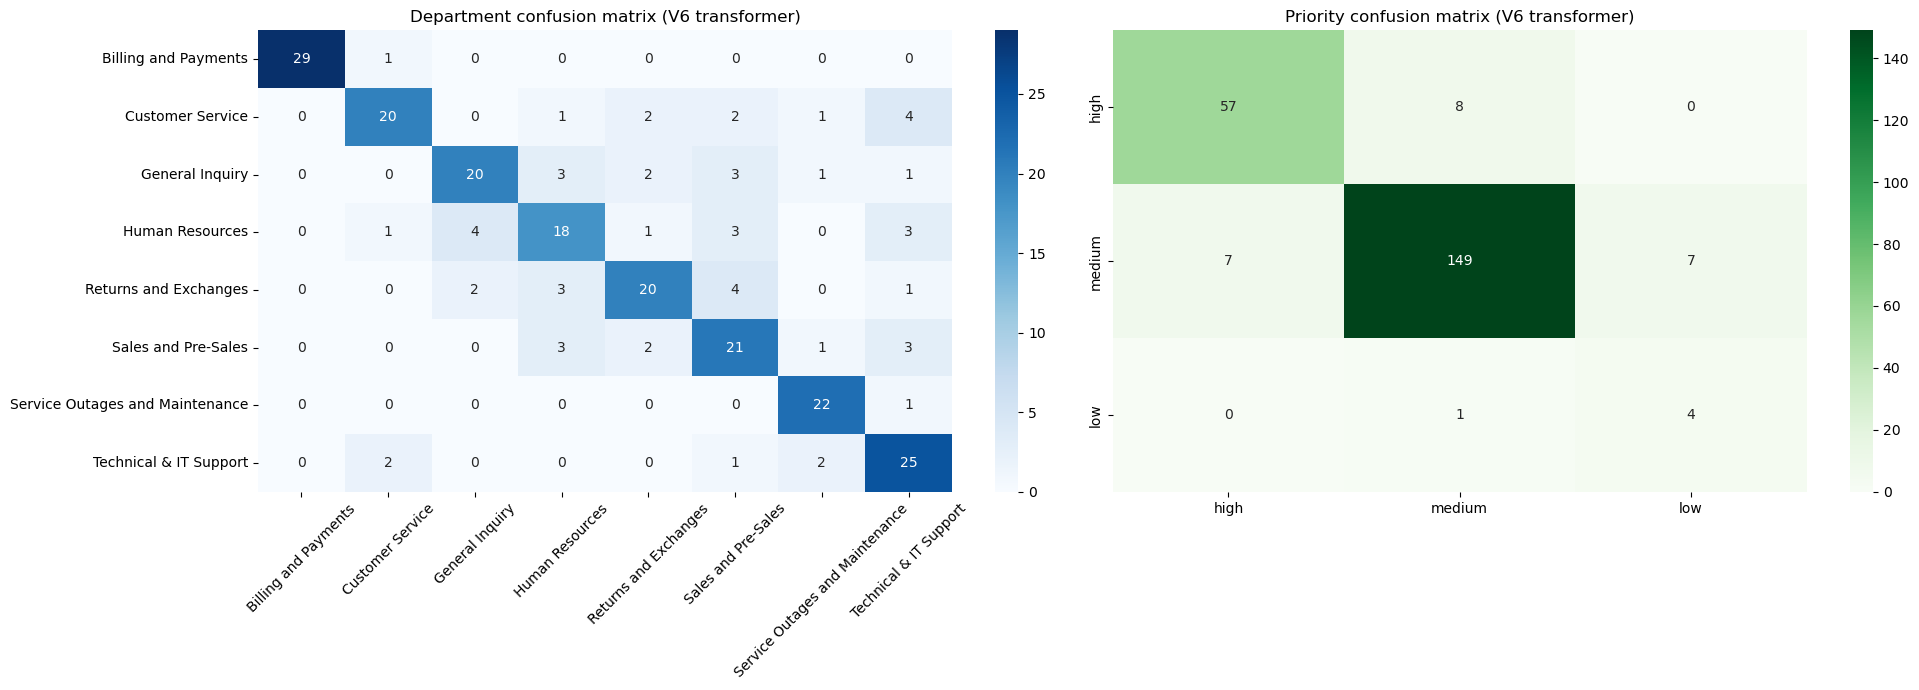

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
dept_labels = sorted(trans_df['true_dept'].unique())
prio_labels = ['high', 'medium', 'low']

sns.heatmap(confusion_matrix(trans_df['true_dept'], trans_df['pred_dept'], labels=dept_labels),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=dept_labels, yticklabels=dept_labels, ax=axes[0])
axes[0].set_title('Department confusion matrix (V6 transformer)')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(confusion_matrix(trans_df['true_priority'], trans_df['pred_priority'], labels=prio_labels),
    annot=True, fmt='d', cmap='Greens',
    xticklabels=prio_labels, yticklabels=prio_labels, ax=axes[1])
axes[1].set_title('Priority confusion matrix (V6 transformer)')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'transformer_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

Department ECE: 0.0388  |  Priority ECE: 0.0727  (lower = better calibrated)


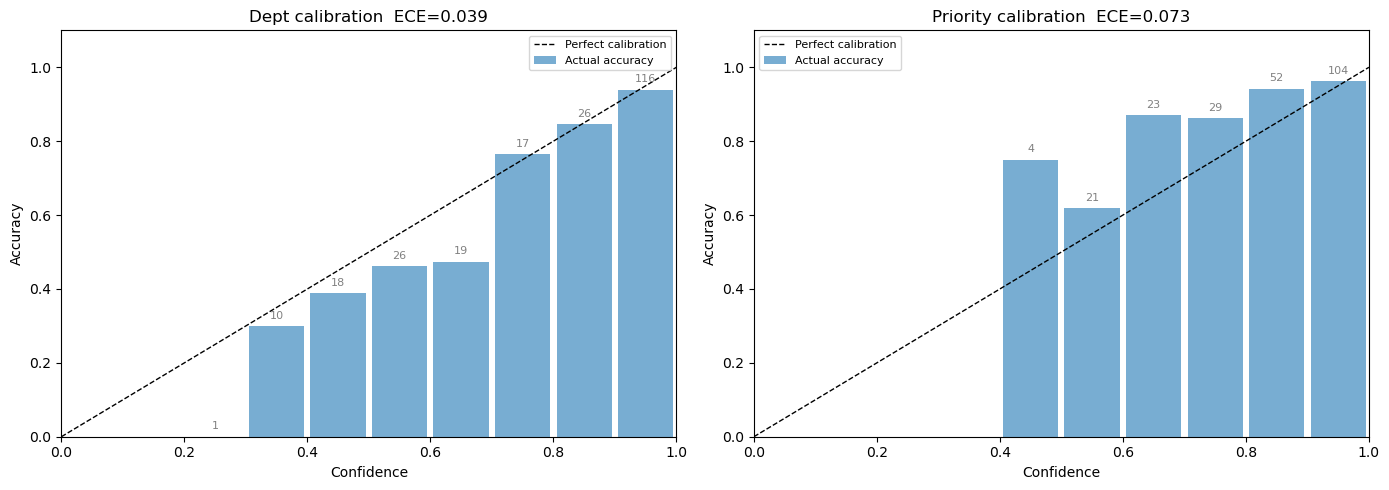

In [7]:
# Confidence calibration + ECE
def calibration_data(df, conf_col, correct_col, n=10):
    bins = np.linspace(0, 1, n + 1)
    mids, accs, counts = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        s = df[(df[conf_col] >= lo) & (df[conf_col] < hi)]
        if len(s) == 0: continue
        mids.append((lo+hi)/2); accs.append(s[correct_col].mean()); counts.append(len(s))
    return np.array(mids), np.array(accs), np.array(counts)

def ece(mids, accs, counts):
    return float(np.sum(counts * np.abs(mids - accs)) / counts.sum())

trans_df['dept_correct'] = (trans_df['pred_dept']     == trans_df['true_dept']).astype(int)
trans_df['prio_correct'] = (trans_df['pred_priority'] == trans_df['true_priority']).astype(int)

d_m, d_a, d_c = calibration_data(trans_df, 'dept_conf',     'dept_correct')
p_m, p_a, p_c = calibration_data(trans_df, 'priority_conf', 'prio_correct')
dept_ece = ece(d_m, d_a, d_c)
prio_ece = ece(p_m, p_a, p_c)
print(f'Department ECE: {dept_ece:.4f}  |  Priority ECE: {prio_ece:.4f}  (lower = better calibrated)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mids, accs, counts, ece_val, title in [
    (axes[0], d_m, d_a, d_c, dept_ece, f'Dept calibration  ECE={dept_ece:.3f}'),
    (axes[1], p_m, p_a, p_c, prio_ece, f'Priority calibration  ECE={prio_ece:.3f}'),
]:
    w = mids[1]-mids[0] if len(mids)>1 else 0.1
    ax.bar(mids, accs, width=w*0.9, alpha=0.6, label='Actual accuracy')
    ax.plot([0,1],[0,1],'k--',lw=1,label='Perfect calibration')
    for m,a,c in zip(mids,accs,counts): ax.text(m,a+0.02,str(c),ha='center',fontsize=8,color='grey')
    ax.set_xlim(0,1); ax.set_ylim(0,1.1)
    ax.set_xlabel('Confidence'); ax.set_ylabel('Accuracy')
    ax.set_title(title); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'calibration_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 2 — RAG Retrieval (Stage 2b)
No API calls. Uses `all-MiniLM-L6-v2` embedder + BGE reranker (V6 — fixes domain mismatch).
Evaluates whether the correct dept chunk and priority chunk are retrieved.

In [8]:
def tokenize_bm25(text):
    return re.sub(r'[^\w\s]', ' ', text.lower()).split()


def retrieve_dept(query, top_n=4):
    """Identical retrieval logic to stage2b_retriever.hybrid_retrieve."""
    q_emb = embedder.encode([query], normalize_embeddings=True).astype('float32')
    _, dense_ids = faiss_index.search(q_emb, 10)
    dense_ids    = dense_ids[0].tolist()

    bm25_scores = bm25.get_scores(tokenize_bm25(query))
    bm25_ids    = np.argsort(bm25_scores)[::-1][:10].tolist()

    rrf = {}
    for rank, idx in enumerate(dense_ids):
        rrf[idx] = rrf.get(idx, 0) + 1.0 / (60 + rank + 1)
    for rank, idx in enumerate(bm25_ids):
        rrf[idx] = rrf.get(idx, 0) + 1.0 / (60 + rank + 1)

    candidate_ids = [i for i, _ in sorted(rrf.items(), key=lambda x: x[1], reverse=True)[:20]]
    raw_scores    = cross_encoder.predict([[query, all_chunks[i]['text']] for i in candidate_ids])
    ce_scores     = [1 / (1 + math.exp(-s)) for s in raw_scores]  # sigmoid — BGE outputs raw logits
    ranked        = sorted(zip(candidate_ids, ce_scores), key=lambda x: x[1], reverse=True)

    return [
        {'chunk': all_chunks[idx], 'ce_score': float(score)}
        for idx, score in ranked[:top_n]
    ]


def retrieve_priority(query):
    q_emb = embedder.encode([query], normalize_embeddings=True).astype('float32')
    k     = min(len(priority_chunks), 3)
    _, ids = priority_index.search(q_emb, k)
    cand   = ids[0].tolist()
    raw    = cross_encoder.predict([[query, priority_chunks[i]['text']] for i in cand])
    ce     = [1 / (1 + math.exp(-s)) for s in raw]
    best   = int(np.argmax(ce))
    return {'chunk': priority_chunks[cand[best]], 'ce_score': float(ce[best])}


if os.path.exists(RAG_RESULTS_PATH):
    rag_df = pd.read_csv(RAG_RESULTS_PATH)
    print(f'Loaded cached RAG results ({len(rag_df)} rows)')
else:
    records = []
    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
        query     = row['raw_text']
        true_dept = row['queue']
        true_prio = row['priority'].lower()

        chunks = retrieve_dept(query, top_n=4)
        depts  = [c['chunk']['dept'] for c in chunks]
        scores = [c['ce_score']      for c in chunks]
        r1     = int(depts[0] == true_dept) if depts else 0
        r4     = int(true_dept in depts)
        mrr    = next((1.0/(r+1) for r,d in enumerate(depts) if d==true_dept), 0.0)

        pc        = retrieve_priority(query)
        prio_sect = pc['chunk']['section'].lower()
        prio_ce   = pc['ce_score']

        records.append({
            'true_dept'    : true_dept,   'true_priority': true_prio,
            'top1_dept'    : depts[0] if depts else '',
            'recall_at_1'  : r1,          'recall_at_4'  : r4,
            'mrr'          : mrr,          'top_ce_score' : scores[0] if scores else 0.0,
            'prio_section' : prio_sect,    'prio_ce_score': prio_ce,
            'prio_correct' : int(prio_sect == true_prio),
        })

    rag_df = pd.DataFrame(records)
    rag_df.to_csv(RAG_RESULTS_PATH, index=False)
    print(f'Saved {len(rag_df)} rows')

100%|██████████| 233/233 [01:27<00:00,  2.68it/s]

Saved 233 rows


In [9]:
print('=' * 55)
print('RAG RETRIEVAL RESULTS (V6 — all-MiniLM + BGE reranker)')
print('=' * 55)
print(f'Dept  Recall@1 : {rag_df["recall_at_1"].mean()*100:.1f}%')
print(f'Dept  Recall@4 : {rag_df["recall_at_4"].mean()*100:.1f}%')
print(f'Dept  MRR      : {rag_df["mrr"].mean():.3f}')
print(f'Prio  Section  : {rag_df["prio_correct"].mean()*100:.1f}%  (random baseline 33.3%)')
print()
print('Recall@1 per department:')
per_dept = rag_df.groupby('true_dept')['recall_at_1'].agg(['mean','count']).rename(
    columns={'mean':'Recall@1','count':'N'}).sort_values('Recall@1', ascending=False)
per_dept['Recall@1'] = (per_dept['Recall@1']*100).round(1).astype(str)+'%'
print(per_dept)

print(f'\nCE score distribution (after sigmoid):')
print(f'  Mean top CE   : {rag_df["top_ce_score"].mean():.3f}')
print(f'  Median top CE : {rag_df["top_ce_score"].median():.3f}')
print(f'  Min / Max     : {rag_df["top_ce_score"].min():.3f} / {rag_df["top_ce_score"].max():.3f}')

RAG RETRIEVAL RESULTS (V6 — all-MiniLM + BGE reranker)
Dept  Recall@1 : 39.9%
Dept  Recall@4 : 62.7%
Dept  MRR      : 0.491
Prio  Section  : 49.4%  (random baseline 33.3%)

Recall@1 per department:
                                Recall@1   N
true_dept                                   
Billing and Payments               86.7%  30
Service Outages and Maintenance    56.5%  23
Customer Service                   50.0%  30
Returns and Exchanges              43.3%  30
Human Resources                    40.0%  30
Sales and Pre-Sales                30.0%  30
General Inquiry                    16.7%  30
Technical & IT Support              0.0%  30

CE score distribution (after sigmoid):
  Mean top CE   : 0.612
  Median top CE : 0.613
  Min / Max     : 0.501 / 0.731


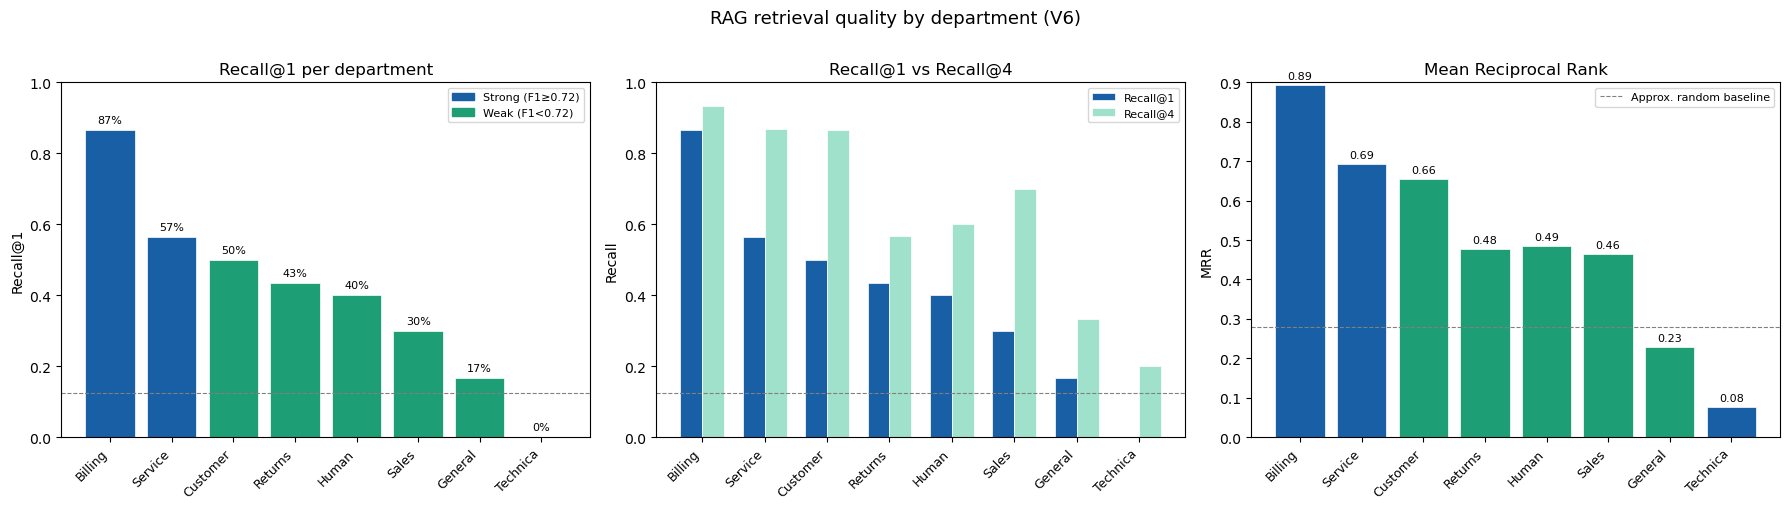

In [10]:
import matplotlib.patches as mpatches

depts_sorted = rag_df.groupby('true_dept')['recall_at_1'].mean().sort_values(ascending=False).index.tolist()
short = [d.replace(' and ', '\n').replace(' & ', '\n').split()[0][:8] for d in depts_sorted]

# V6 F1 scores from training eval — used to colour weak vs strong classes
DEPT_F1 = {
    'Billing and Payments':            0.99,
    'Customer Service':                0.60,
    'General Inquiry':                 0.64,
    'Human Resources':                 0.65,
    'Returns and Exchanges':           0.68,
    'Sales and Pre-Sales':             0.71,
    'Service Outages and Maintenance': 0.76,
    'Technical & IT Support':          0.78,
}
is_weak = [DEPT_F1.get(d, 1.0) < 0.72 for d in depts_sorted]
colors  = ['#1D9E75' if w else '#185FA5' for w in is_weak]

r1_  = rag_df.groupby('true_dept')['recall_at_1'].mean().reindex(depts_sorted).values
r4_  = rag_df.groupby('true_dept')['recall_at_4'].mean().reindex(depts_sorted).values
mrr_ = rag_df.groupby('true_dept')['mrr'].mean().reindex(depts_sorted).values
x, w = np.arange(len(depts_sorted)), 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RAG retrieval quality by department (V6)', fontsize=13, y=1.01)

bars = axes[0].bar(x, r1_, color=colors, edgecolor='white', linewidth=0.5)
axes[0].axhline(1/8, color='grey', linestyle='--', lw=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(short, rotation=45, ha='right', fontsize=9)
axes[0].set_ylim(0,1); axes[0].set_ylabel('Recall@1'); axes[0].set_title('Recall@1 per department')
for b,v in zip(bars,r1_): axes[0].text(b.get_x()+b.get_width()/2,v+0.02,f'{v*100:.0f}%',ha='center',fontsize=8)
axes[0].legend(handles=[mpatches.Patch(color='#185FA5',label='Strong (F1≥0.72)'),
                         mpatches.Patch(color='#1D9E75',label='Weak (F1<0.72)')],fontsize=8)

axes[1].bar(x-w/2, r1_, w, label='Recall@1', color='#185FA5', edgecolor='white', linewidth=0.5)
axes[1].bar(x+w/2, r4_, w, label='Recall@4', color='#9FE1CB', edgecolor='white', linewidth=0.5)
axes[1].axhline(1/8, color='grey', linestyle='--', lw=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(short, rotation=45, ha='right', fontsize=9)
axes[1].set_ylim(0,1); axes[1].set_ylabel('Recall')
axes[1].set_title('Recall@1 vs Recall@4'); axes[1].legend(fontsize=8)

bars3 = axes[2].bar(x, mrr_, color=colors, edgecolor='white', linewidth=0.5)
axes[2].axhline(0.28, color='grey', linestyle='--', lw=0.8, label='Approx. random baseline')
axes[2].set_xticks(x); axes[2].set_xticklabels(short, rotation=45, ha='right', fontsize=9)
axes[2].set_ylim(0,0.9); axes[2].set_ylabel('MRR')
axes[2].set_title('Mean Reciprocal Rank'); axes[2].legend(fontsize=8)
for b,v in zip(bars3,mrr_): axes[2].text(b.get_x()+b.get_width()/2,v+0.015,f'{v:.2f}',ha='center',fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'rag_retrieval_by_dept.png'),dpi=150,bbox_inches='tight')
plt.show()

---
## Section 3 — Full Pipeline: Accuracy + Latency

**Stage 1** always runs (Groq rewrite). **Stage 3 LLM** only runs when transformer confidence is below per-class threshold — otherwise fast path.

**TTFT** = Stage 1 latency — the first blocking LLM call.

**TPOT** = Stage 3 estimated latency / output tokens. Stage 3 generates a reasoning paragraph — TPOT varies with ticket complexity.

In [11]:
print('Measuring TTFT baseline (Stage 1 warm-up)...')
_t0 = time.perf_counter()
_ = _stage1(pipeline_df.iloc[0]['raw_text'], groq_client)
TTFT_BASELINE = round(time.perf_counter() - _t0, 3)
print(f'TTFT baseline: {TTFT_BASELINE:.3f}s')
time.sleep(2.0)

# Per-class thresholds (V6)
DEPT_THRESHOLDS = {
    'Billing and Payments':            0.72,
    'Customer Service':                0.60,
    'General Inquiry':                 0.65,
    'Human Resources':                 0.65,
    'Returns and Exchanges':           0.72,
    'Sales and Pre-Sales':             0.72,
    'Service Outages and Maintenance': 0.60,
    'Technical & IT Support':          0.72,
}
PRIORITY_THRESHOLD = 0.65

if os.path.exists(PIPELINE_RESULTS_PATH):
    _ex = pd.read_csv(PIPELINE_RESULTS_PATH)
    if len(_ex) > 0 and 'pred_dept' in _ex.columns:
        results_df = _ex
        print(f'Loaded cached pipeline results ({len(results_df)} rows)')
    else:
        os.remove(PIPELINE_RESULTS_PATH)

if not os.path.exists(PIPELINE_RESULTS_PATH):
    records, errors = [], 0
    for idx, row in tqdm(pipeline_df.iterrows(), total=len(pipeline_df)):
        try:
            t0  = time.perf_counter()
            res = route_ticket(
                row['raw_text'], groq_client,
                model, tokenizer, queue_encoder, priority_encoder, device,
                embedder,
                faiss_index, bm25, all_chunks, cross_encoder,
                priority_index, priority_chunks
            )
            t_total          = round(time.perf_counter() - t0, 3)
            reasoning_tokens = max(len(res.reasoning.split()), 1)
            t_stage3_est     = max(t_total - TTFT_BASELINE - 0.05, 0.1)
            dept_thr         = DEPT_THRESHOLDS.get(res.transformer_dept, 0.70)
            fast_path        = (res.transformer_conf >= dept_thr and
                                res.priority_probs.get(res.priority, 0) >= PRIORITY_THRESHOLD)
            records.append({
                'true_dept'         : row['queue'],
                'true_priority'     : row['priority'],
                'pred_dept'         : res.department,
                'pred_priority'     : res.priority,
                'transformer_dept'  : res.transformer_dept,
                'transformer_conf'  : res.transformer_conf,
                'confidence'        : res.confidence,
                'llm_overrides_dept': int(res.department != res.transformer_dept),
                'fast_path'         : int(fast_path),
                't_total_s'         : t_total,
                'ttft_s'            : TTFT_BASELINE,
                'tpot_s'            : round(t_stage3_est / reasoning_tokens, 4),
                'reasoning_tokens'  : reasoning_tokens,
            })
        except Exception as e:
            if '429' in str(e) or 'rate_limit' in str(e).lower():
                pd.DataFrame(records).to_csv(PIPELINE_RESULTS_PATH, index=False)
                wait = 60
                print(f'\n⚠ Rate limit at row {idx} — waiting {wait}s then retrying...')
                time.sleep(wait)
                try:
                    t0  = time.perf_counter()
                    res = route_ticket(
                        row['raw_text'], groq_client,
                        model, tokenizer, queue_encoder, priority_encoder, device,
                        embedder,
                        faiss_index, bm25, all_chunks, cross_encoder,
                        priority_index, priority_chunks
                    )
                    t_total          = round(time.perf_counter() - t0, 3)
                    reasoning_tokens = max(len(res.reasoning.split()), 1)
                    t_stage3_est     = max(t_total - TTFT_BASELINE - 0.05, 0.1)
                    dept_thr         = DEPT_THRESHOLDS.get(res.transformer_dept, 0.70)
                    fast_path        = (res.transformer_conf >= dept_thr and
                                        res.priority_probs.get(res.priority, 0) >= PRIORITY_THRESHOLD)
                    records.append({
                        'true_dept': row['queue'], 'true_priority': row['priority'],
                        'pred_dept': res.department, 'pred_priority': res.priority,
                        'transformer_dept': res.transformer_dept, 'transformer_conf': res.transformer_conf,
                        'confidence': res.confidence, 'llm_overrides_dept': int(res.department != res.transformer_dept),
                        'fast_path': int(fast_path), 't_total_s': t_total, 'ttft_s': TTFT_BASELINE,
                        'tpot_s': round(t_stage3_est/reasoning_tokens, 4), 'reasoning_tokens': reasoning_tokens,
                    })
                except Exception as e2:
                    errors += 1
                    print(f'✗ Retry failed for row {idx}: {e2}')
                    records.append({'true_dept': row['queue'], 'true_priority': row['priority'],
                                    'pred_dept': 'ERROR', 'pred_priority': 'ERROR',
                                    'transformer_dept': '', 'transformer_conf': 0.0,
                                    'confidence': 'low', 'llm_overrides_dept': 0, 'fast_path': 0,
                                    't_total_s': None, 'ttft_s': None, 'tpot_s': None, 'reasoning_tokens': 0})
            else:
                errors += 1
                print(f'✗ Row {idx}: {e}')
                records.append({'true_dept': row['queue'], 'true_priority': row['priority'],
                                'pred_dept': 'ERROR', 'pred_priority': 'ERROR',
                                'transformer_dept': '', 'transformer_conf': 0.0,
                                'confidence': 'low', 'llm_overrides_dept': 0, 'fast_path': 0,
                                't_total_s': None, 'ttft_s': None, 'tpot_s': None, 'reasoning_tokens': 0})
        time.sleep(1.5)

    results_df = pd.DataFrame(records)
    results_df.to_csv(PIPELINE_RESULTS_PATH, index=False)
    print(f'Saved {len(results_df)} tickets ({errors} errors)')

if 'results_df' not in dir():
    results_df = pd.read_csv(PIPELINE_RESULTS_PATH)

Measuring TTFT baseline (Stage 1 warm-up)...
16:57:31  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (487 chars)
16:57:31  DEBUG     [stage1.rewriter]  Raw input: 'is requesting an update to user access rights within the HR system for employees utilizing various integrated software t'
  ⚠ Token exhausted — switching to token 2
16:57:32  INFO      [stage1.rewriter]  Stage 1 done — subject: 'Update User Access Rights in HR System'
16:57:32  DEBUG     [stage1.rewriter]  Urgency signals : []
16:57:32  DEBUG     [stage1.rewriter]  Tech keywords   : ['HR system', 'integrated software tools']
16:57:32  DEBUG     [stage1.rewriter]  Explanation     : This issue is likely related to the IT department because it involves updating user access rights and integrated software tools.
16:57:32  DEBUG     [stage1.rewriter]  Cleaned text: 'We are requesting an update to user access rights within the HR system for employees utilizing various integrated softwa'
TTFT baseline: 1.537s


  0%|          | 0/80 [00:00<?, ?it/s]

16:57:35  INFO      [router]  ============================================================
16:57:35  INFO      [router]  NEW TICKET (487 chars): 'is requesting an update to user access rights within the HR system for employees'
16:57:35  INFO      [router]  ============================================================
16:57:35  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (487 chars)
16:57:35  DEBUG     [stage1.rewriter]  Raw input: 'is requesting an update to user access rights within the HR system for employees utilizing various integrated software t'
16:57:35  WARNING   [stage1.rewriter]  Partial JSON — extracted structured_body via regex
16:57:35  WARNING   [stage1.rewriter]  Stage 1 — JSON parse failed, using cleaned fallback
16:57:35  DEBUG     [stage1.rewriter]  Cleaned text: 'We are requesting an update to user access rights within the HR system for employees utilizing various integrated softwa'
16:57:35  DEBUG     [stage2a.transformer]  Predicting on (486 chars): 'We

  1%|▏         | 1/80 [00:02<03:55,  2.98s/it]

16:57:37  INFO      [router]  ============================================================
16:57:37  INFO      [router]  NEW TICKET (312 chars): 'The client was billed incorrectly on the most recent invoice, likely due to an e'
16:57:37  INFO      [router]  ============================================================
16:57:37  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (312 chars)
16:57:37  DEBUG     [stage1.rewriter]  Raw input: 'The client was billed incorrectly on the most recent invoice, likely due to an error in the billing system. After examin'
16:57:38  INFO      [stage1.rewriter]  Stage 1 done — subject: 'Incorrect Billing on Recent Invoice'
16:57:38  DEBUG     [stage1.rewriter]  Urgency signals : ['expedited response']
16:57:38  DEBUG     [stage1.rewriter]  Tech keywords   : ['billing system']
16:57:38  DEBUG     [stage1.rewriter]  Explanation     : The client's issue is likely related to the billing department due to the mention of an incorrect invoice and billin

...

17:01:35  INFO      [router]  ============================================================
17:01:35  INFO      [router]  NEW TICKET (549 chars): 'I am currently facing a problem with logging into my account, which is causing a'
17:01:35  INFO      [router]  ============================================================
17:01:35  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (549 chars)
17:01:35  DEBUG     [stage1.rewriter]  Raw input: 'I am currently facing a problem with logging into my account, which is causing a lot of inconvenience. Here are the deta'
17:01:35  INFO      [stage1.rewriter]  Stage 1 done — subject: 'Login Issue With Account Access'
17:01:35  DEBUG     [stage1.rewriter]  Urgency signals : ['causing a lot of inconvenience']
17:01:35  DEBUG     [stage1.rewriter]  Tech keywords   : ['browser', 'cookie issues', 'cache']
17:01:35  DEBUG     [stage1.rewriter]  Explanation     : The customer is likely to be directed to the IT or login support department.
17:01:35  DE

 99%|█████████▉| 79/80 [04:02<00:02,  2.56s/it]

17:01:37  INFO      [router]  ============================================================
17:01:37  INFO      [router]  NEW TICKET (501 chars): 'Our company is considering adopting these solutions to streamline our current ma'
17:01:37  INFO      [router]  ============================================================
17:01:37  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (501 chars)
17:01:37  DEBUG     [stage1.rewriter]  Raw input: 'Our company is considering adopting these solutions to streamline our current marketing processes and wants to confirm t'
  ⚠ Token exhausted — switching to token 5
17:01:38  INFO      [stage1.rewriter]  Stage 1 done — subject: 'Compatibility with Marketing Software'
17:01:38  DEBUG     [stage1.rewriter]  Urgency signals : []
17:01:38  DEBUG     [stage1.rewriter]  Tech keywords   : ['marketing software', 'CRM systems', 'email marketing applications', 'analytics platforms']
17:01:38  DEBUG     [stage1.rewriter]  Explanation     : The customer is l

100%|██████████| 80/80 [04:04<00:00,  3.06s/it]

Saved 80 tickets (0 errors)


In [12]:
from sklearn.metrics import classification_report, confusion_matrix

clean = results_df[results_df['pred_dept'] != 'ERROR'].copy()
clean['dept_correct']  = (clean['pred_dept']       == clean['true_dept']).astype(int)
clean['prio_correct']  = (clean['pred_priority']   == clean['true_priority']).astype(int)
clean['trans_correct'] = (clean['transformer_dept'] == clean['true_dept']).astype(int)

print('=' * 60)
print('FULL PIPELINE END-TO-END (V6)')
print('=' * 60)
print(f'Department Accuracy : {clean["dept_correct"].mean()*100:.1f}%')
print(f'Priority   Accuracy : {clean["prio_correct"].mean()*100:.1f}%')
print(f'Total tickets       : {len(clean)}')
print(f'Fast path tickets   : {clean["fast_path"].sum()} ({clean["fast_path"].mean()*100:.1f}%)')
print()

overrides  = clean[clean['llm_overrides_dept'] == 1]
agreements = clean[clean['llm_overrides_dept'] == 0]
print(f'LLM agreed with transformer : {len(agreements)} tickets')
print(f'  Dept accuracy             : {agreements["dept_correct"].mean()*100:.1f}%')
print()
print(f'LLM overrode transformer    : {len(overrides)} tickets ({len(overrides)/max(len(clean),1)*100:.1f}%)')
if len(overrides) > 0:
    trans_on_ov = overrides['trans_correct'].mean()
    llm_on_ov   = overrides['dept_correct'].mean()
    delta       = (llm_on_ov - trans_on_ov) * 100
    print(f'  Transformer accuracy on overridden tickets : {trans_on_ov*100:.1f}%')
    print(f'  LLM final accuracy on overridden tickets   : {llm_on_ov*100:.1f}%')
    print(f'  LLM override improvement                   : {delta:+.1f}pp')
    print(f'  (positive = LLM corrected transformer mistakes)')

print()
print('DEPARTMENT CLASSIFICATION REPORT (full pipeline):')
print(classification_report(clean['true_dept'], clean['pred_dept'], zero_division=0))
print('PRIORITY CLASSIFICATION REPORT (full pipeline):')
print(classification_report(clean['true_priority'], clean['pred_priority'], zero_division=0))

FULL PIPELINE END-TO-END (V6)
Department Accuracy : 65.0%
Priority   Accuracy : 86.2%
Total tickets       : 80
Fast path tickets   : 48 (60.0%)

LLM agreed with transformer : 66 tickets
  Dept accuracy             : 77.3%

LLM overrode transformer    : 14 tickets (17.5%)
  Transformer accuracy on overridden tickets : 42.9%
  LLM final accuracy on overridden tickets   : 7.1%
  LLM override improvement                   : -35.7pp
  (positive = LLM corrected transformer mistakes)

DEPARTMENT CLASSIFICATION REPORT (full pipeline):
                                 precision    recall  f1-score   support

           Billing and Payments       1.00      0.90      0.95        10
               Customer Service       0.55      0.60      0.57        10
                General Inquiry       0.33      0.30      0.32        10
                Human Resources       1.00      0.60      0.75        10
          Returns and Exchanges       1.00      0.30      0.46        10
            Sales and Pre-Sa

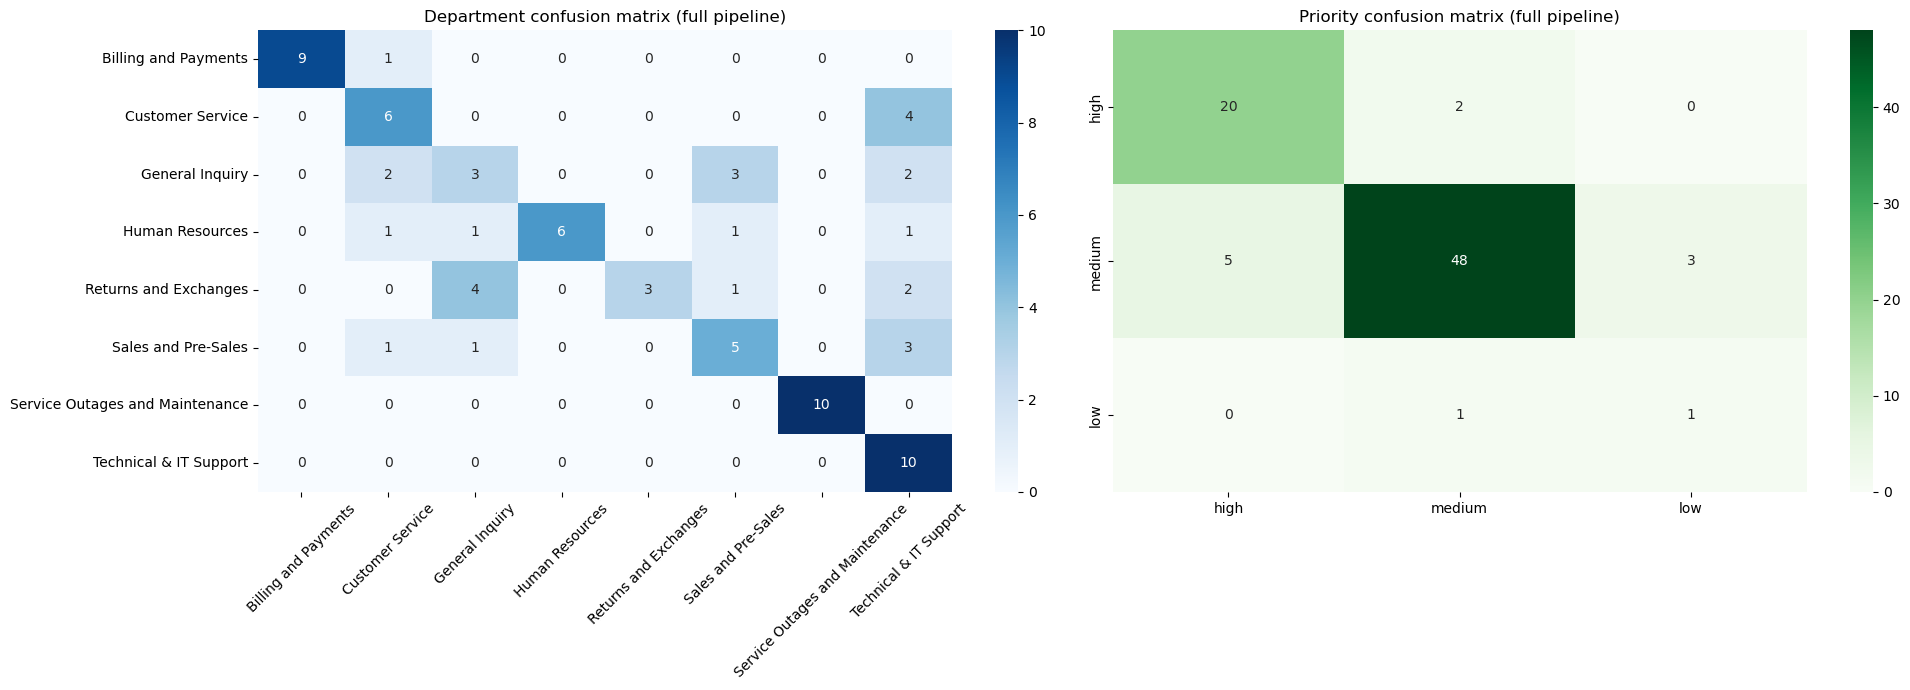

In [13]:
dept_labels = sorted(clean['true_dept'].unique())
prio_labels = ['high', 'medium', 'low']

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.heatmap(confusion_matrix(clean['true_dept'], clean['pred_dept'], labels=dept_labels),
    annot=True, fmt='d', cmap='Blues', xticklabels=dept_labels, yticklabels=dept_labels, ax=axes[0])
axes[0].set_title('Department confusion matrix (full pipeline)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(confusion_matrix(clean['true_priority'], clean['pred_priority'], labels=prio_labels),
    annot=True, fmt='d', cmap='Greens', xticklabels=prio_labels, yticklabels=prio_labels, ax=axes[1])
axes[1].set_title('Priority confusion matrix (full pipeline)', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'pipeline_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

LATENCY METRICS
TTFT — Stage 1 rewrite (first blocking Groq call):
  Measured baseline : 1.537s

End-to-end latency (all stages):
  Mean   : 1.552s
  Median : 0.982s
  P90    : 2.625s

TPOT — Stage 3 output (reasoning paragraph):
  Mean   : 0.0151s/token
  Median : 0.0050s/token
  Avg reasoning tokens : 44
  Reference: human reading ~0.125-0.167s/token (6-8 tokens/s)

Fast path (no Stage 3 LLM): 60.0% of tickets


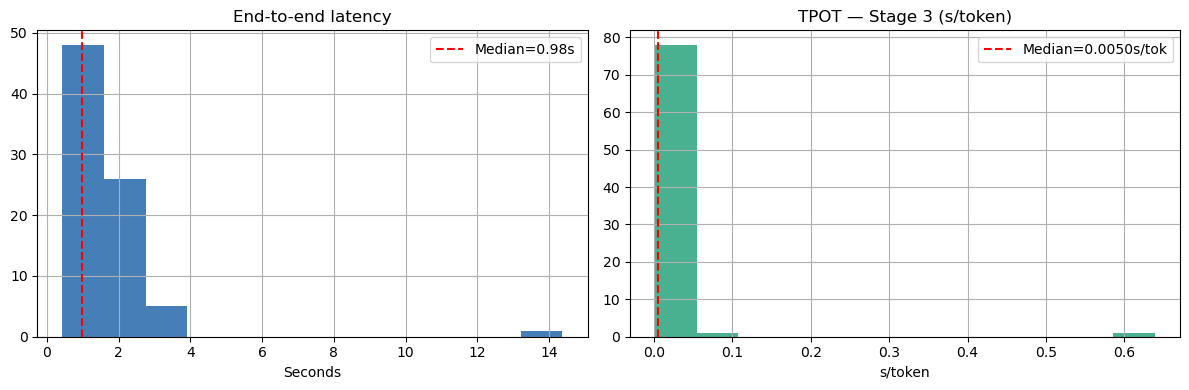

In [14]:
lat = clean[clean['t_total_s'].notna()]

print('=' * 60)
print('LATENCY METRICS')
print('=' * 60)
print(f'TTFT — Stage 1 rewrite (first blocking Groq call):')
print(f'  Measured baseline : {TTFT_BASELINE:.3f}s')
print()
print(f'End-to-end latency (all stages):')
print(f'  Mean   : {lat["t_total_s"].mean():.3f}s')
print(f'  Median : {lat["t_total_s"].median():.3f}s')
print(f'  P90    : {lat["t_total_s"].quantile(0.9):.3f}s')
print()
tpot_vals = lat[lat['tpot_s'].notna()]['tpot_s']
print(f'TPOT — Stage 3 output (reasoning paragraph):')
print(f'  Mean   : {tpot_vals.mean():.4f}s/token')
print(f'  Median : {tpot_vals.median():.4f}s/token')
print(f'  Avg reasoning tokens : {lat["reasoning_tokens"].mean():.0f}')
print(f'  Reference: human reading ~0.125-0.167s/token (6-8 tokens/s)')
print()
print(f'Fast path (no Stage 3 LLM): {clean["fast_path"].mean()*100:.1f}% of tickets')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
lat['t_total_s'].hist(bins=12, ax=axes[0], color='#185FA5', alpha=0.8)
axes[0].axvline(lat['t_total_s'].median(), color='red', linestyle='--',
                label=f'Median={lat["t_total_s"].median():.2f}s')
axes[0].set_title('End-to-end latency'); axes[0].set_xlabel('Seconds'); axes[0].legend()

tpot_vals.hist(bins=12, ax=axes[1], color='#1D9E75', alpha=0.8)
axes[1].axvline(tpot_vals.median(), color='red', linestyle='--',
                label=f'Median={tpot_vals.median():.4f}s/tok')
axes[1].set_title('TPOT — Stage 3 (s/token)'); axes[1].set_xlabel('s/token'); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'latency_distributions.png'),dpi=150,bbox_inches='tight')
plt.show()